## **Métricas para Classificação**

São métricas utilizadas para avaliar o **desempenho dos modelos de classificação**.

Para melhro compreensão das métricas, vamos usar o **algoritmo KNN** e o [**Iris Flower Dataset**](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html).

### **Conjunto de Dados**

Dado um conjunto de observações:

$$
\mathcal{D} = \{(\mathbb{x}_i, y_{i})\}_{i=1}^{N}
$$

tal que $\mathbb{x}_i \in \mathbb{R}^{D}$ e $y_i \in \mathcal{C}$ onde $\mathcal{C} = \{c_i\}_{i=1}^{K}$ é o conjunto das classes.

In [48]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


In [51]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [52]:
y_pred = knn.predict(X_test)

### **Matriz de Confusão**

A matriz de confusão $C \in \mathbb{R}^{K \times K}$ é definida como:

$$
C_{i,j} := \# \text {exemplos cuja classe é $i$ e foi prevista como $j$}
$$

Dessa forma segue que:

*   **Diagonal Principal ($i = j$)**: Classificações Corretas
*   **Fora da Diagonal Principal ($i \neq j$)**: Classifições Erradas

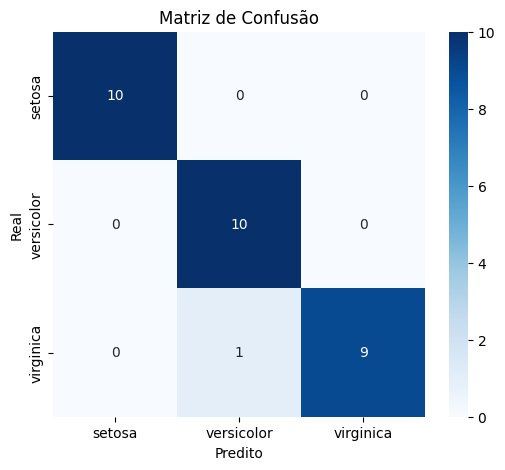

In [53]:
from sklearn.metrics import confusion_matrix

labels = sorted(df['species'].unique())
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

#### **Accuracy**

A acurácia mede a proporção de exemplos corretamente classificados:

$$
\text{Accuracy} := \dfrac{\text{# Pedições Corretas}}{\text{# Predições}}
$$

ou seja:

$$
\text{Accuracy} = \dfrac{\displaystyle\sum_{i=1}^{K} C_{ii}}
{\displaystyle\sum_{i=1}^{K}\displaystyle\sum_{j=1}^{K} C_{ij}}
$$

In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {100 * round(accuracy, 4)}%")

Accuracy: 96.67%


#### **Precision**

A precisão para a classe $c_i$ mede a proporção de exemplos classificados como $c_i$ que são realmente dessa classe:

$$
\text{Precision}_i := \dfrac{\text{# Pedições Corretas para $c_i$}}{\text{# Predições para $c_i$}}
$$

ou seja:

$$
\text{Precision}_i = \dfrac{C_{ii}}{\displaystyle\sum_{j=1}^{K} C_{ji}}
$$

In [55]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, average=None)

for i, p in enumerate(precision):
  print(f"Recall para classe {labels[i]}: {100 * round(p, 4)}%")

Recall para classe setosa: 100.0%
Recall para classe versicolor: 90.91%
Recall para classe virginica: 100.0%


#### **Recall**

A recall para a classe $c_i$ mede a proporção de exemplos reais de $c_i$ que foram corretamente identificados:

$$
\text{Recall}_i := \dfrac{\text{# Pedições Corretas para $c_i$}}{\text{# Exemplos Reais de $c_i$}}
$$

ou seja:

$$
\text{Recall}_i = \dfrac{C_{ii}}{\displaystyle\sum_{j=1}^{K} C_{ij}}
$$

In [56]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred, average=None)

for i, r in enumerate(recall):
  print(f"Recall para classe {labels[i]}: {100 * round(r, 4)}%")

Recall para classe setosa: 100.0%
Recall para classe versicolor: 100.0%
Recall para classe virginica: 90.0%


#### **F1-Score**

Combina precisão e recall em uma única métrica:

$$
\text{F1}_i = 2 \cdot \dfrac{\text{Precision}_i \cdot \text{Recall}_i}
{\text{Precision}_i + \text{Recall}_i}
$$

É útil quando há desbalanceamento de classes, equilibrando precisão e recall

In [57]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average=None)

for i, f in enumerate(recall):
  print(f"F1-Score para classe {labels[i]}: {100 * round(f, 4)}%")

F1-Score para classe setosa: 100.0%
F1-Score para classe versicolor: 100.0%
F1-Score para classe virginica: 90.0%


## **Comparação entre Modelos**